# Dimensionality Reduction Using Principal Component Analysis
_**Apply Principal Component Analysis (PCA) to reduce an appropriate dataset preserving a given explained variance**_

In [ ]:
# Import required packages

import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import pickle

## Retrieval & Preparation of Data

In [6]:
with open("./../../data/mnist_784.pickle", "rb") as file:
    X_mnist, y_mnist = pickle.load(file)

In [7]:
# Checks the shape of the dataset
print(X_mnist.shape)

(70000, 784)


In [8]:
# Splits dataset into train and test set containing 60000 and 10000 instances, respectively.

X_train, X_test, y_train, y_test = train_test_split(
    X_mnist, y_mnist, test_size=10000, random_state=42, stratify=y_mnist)

## Analyzing Principal Components to Reduce Dimensionality of Dataset

In [9]:
# Creates object instance to analyze principal components of data set
pca = PCA()

In [10]:
# Fits the principal component analyzer on the train set
pca.fit(X_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [11]:
# Shows variance (as ratio) explained by few of the components
# NOTE: Sum of explained variance ratio for all component will add upto 1
print(pca.explained_variance_ratio_[:10])

[0.09742223 0.07146776 0.06142348 0.05407511 0.04880344 0.04300261
 0.03283177 0.02893752 0.02750283 0.02347564]


In [12]:
# Stores sumulative sum of explained variance ratio for all the components
cumsum = np.cumsum(pca.explained_variance_ratio_)

**Choosing the Right Number of Dimensions**

_Let's choose a number of dimensions that add up to a sufficiently large portion of variance of the training dataset. Let's also consider that 95% variance of the training dataset needs to be preserved._

In [13]:
# The following statement computes the minimum number of dimension 
# required to preserve 95% variance of the training set

d = np.argmax(cumsum >= 0.95) + 1
print("Minimum number of dimensions required to preserve 95% variance:", d)

Minimum number of dimensions required to preserve 95% variance: 154


In [14]:
# Instead finding the minimum required dimension manually, as shown above, PCA can find the same for us.

# PCA is initialized with the minimum requirement of explained variance
pca = PCA(n_components=0.95)

# Applies the dimensionality reduction on the train set and it returns minimum number of 
# principal components that can explain a given variance
X_train_reduced = pca.fit_transform(X_train)

# Checks the number of principal components
print("Number of principal components: ", pca.n_components_)

Number of principal components:  154


In [15]:
# [OPTIONAL STEP] Manually adds-up variance ratio of each explained by # each of the principal 
# components and check if the sum is equal or greater than the required explained variance ratio.

print("Explained variance ratio by {0} components: {1: .4}".format(
    pca.n_components_, pca.explained_variance_ratio_.sum()))

Explained variance ratio by 154 components:  0.9504


[]

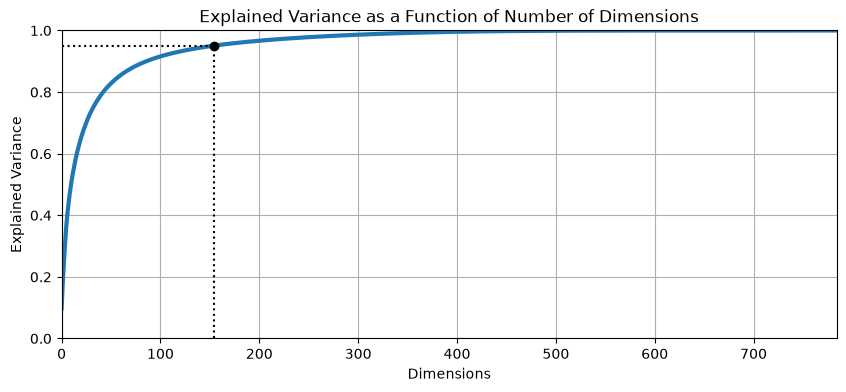

In [17]:
# Draws plot to show explained variance over dimensions

plt.figure(figsize=(10, 4))
plt.plot(cumsum, linewidth = 3)
plt.axis([0, X_mnist.shape[1], 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.grid(True)
plt.title("Explained Variance as a Function of Number of Dimensions")
plt.plot()

It can be noticed from the elbow in above curve that explained variance stops growing faster after a certain number of dimensions

## Modeling Over Reduced Dimensions

**Searches for right combination of dimensions and model hyperparameters.**

For that, modeling pipeline first reduces dimension using `PCA` and then perform classification using a random forest. For hyperparameter tuning `RandomizedSearchCV` is used.

In [18]:
# Creates modeling pipeline

rf_clf = make_pipeline(
    PCA(random_state=42),                    # PCA instance that reduces dimensions
    RandomForestClassifier(random_state=42)) # model instance for making predictions

In [19]:
# Sets hyperparameter distribution
hp = {
    "pca__n_components": np.arange(20, 160),
    "randomforestclassifier__n_estimators": np.arange(100, 500)
}

In [20]:
# Searches for best combination of hyperparameters over cross validation

# Initializes randomize search algorithm
rnd_search = RandomizedSearchCV(
    rf_clf,            # model (modeling pipeline in this case)
    hp,                # Distribution of hyperparameters (all possible mentioned hyperparameters)
    n_iter=20,         # Total nuber of hyperparameter combinations to be sampled [just 20 out of 56000 ((160-20)*(500-100))]
    n_jobs=-1,         # Utilizes all available processors to speed up training
    refit=False,       # Model does not need to be refit with best parameters as test data predictions are not planned here
    cv=3,              # Less cross validation folds instead standard 5 or 10 to save time on training
    random_state=42    # For reproducability of the output
)

# Randomly samples from the given hyperparameters and checks of the current combination is better than the 
# previous one, and the process continues until the mentioned number of iterations get exhausted.
rnd_search.fit(X_train[:10000], y_train[:10000])  # NOTE: This process may take several minutes to complete

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'pca__n_components': array([ 20, ...57, 158, 159]), 'randomforestclassifier__n_estimators': array([100, 1...97, 498, 499])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable 

In [21]:
# Gets the best hyperparameters found
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(365), 'pca__n_components': np.int64(35)}


In [22]:
# Gets the best cross validation score by the random forest model with above mentioned 
# estimators and number of principal components of the data
print("Best Random Forest Model Score:", rnd_search.best_score_)

Best Random Forest Model Score: 0.9299996586341298


**Observations:**
- This prediction performance was achieved over 10000 instances and 20 iterations.
- Mentioned number of training instances and iterations (i.e. 10000 and 20, respectively) were chosen to save time during training. The training on full dataset with more iterations will take much longer during training.
- Random forest model achieved descent score using just 35 components reduced from 784 components.
- The number of reduced components will be different based on the learning algorithm being used. For example, the number of components required would be more for algorithms such as SGDClassifier that is relatively less powerful than random forest.